In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_style('darkgrid')
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore")


from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PowerTransformer
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

from sklearn.model_selection import KFold, ShuffleSplit, LeaveOneOut, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
""" Semilla """
seed = 99


## Primero cargamos la base de datos Saheart
# Obtén el directorio actual del script o cuaderno
# Define el nombre del archivo CSV



#df = pd.read_csv("c:/Users/dagom/Documents/docencia/DOCENCIA_FINAL_2023_PHYTON_ML_DANI/2_Introduccion_y_SVM/SAheart.csv", sep=",", decimal=".")
df = pd.read_csv("winequality-white.csv", sep=";", decimal=".")

df.head()
df.describe()
#df.quantile(np.arange(0,1,0.1))
variables = df.columns.values



In [2]:
display(df.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [4]:
import pandas as pd

quality_counts = df['quality'].value_counts().sort_index()
cross_ref_table = pd.DataFrame({'Quality': quality_counts.index, 'Frequency': quality_counts.values})

# Print the table
print(cross_ref_table)

   Quality  Frequency
0        3         20
1        4        163
2        5       1457
3        6       2198
4        7        880
5        8        175
6        9          5


In [5]:
import pandas as pd

# Crea una nueva columna llamada "quality_binaria"
df['quality_binaria'] = 0  # Inicializa la columna con 0

# Asigna 1 a los valores de "quality" mayores o iguales a 5
df.loc[df['quality'] >= 7, 'quality_binaria'] = 1

# Imprime las primeras filas del dataframe para verificar
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  quality_binaria  
0      8.8        6                0  
1      9

In [6]:
# prompt: borra la variable quality y renombra la variable quality_binaria como y

# Elimina la columna 'quality'
del df['quality']

# Renombra la columna 'quality_binaria' a 'y'
df = df.rename(columns={'quality_binaria': 'y'})


In [8]:
## una pequeña visualizacion
import seaborn as sns
sns.pairplot(df, hue="y",palette="bright")


### Importante que el SVM no funciona bien ni con missing ni con valores no estandarizados

## Paso 1. vemos cuantos missing tenemos en cada variable ##
df.isnull().sum()



Output hidden; open in https://colab.research.google.com to view.

In [ ]:
print(variables)

In [ ]:
## Paso 2. estandarizar
from sklearn import preprocessing

#col_cat = df[['famhist', 'chd']]
col_num = df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH',
 'sulphates', 'alcohol']]


### TIPIFICAMOS O COMO DICEN LOS MODERNOS STANDARIZAMOS.....
scaler = preprocessing.StandardScaler().fit(col_num)
col_num_standarizada = scaler.transform(col_num)

col_num_standarizada.mean(axis=0)
col_num_standarizada.std(axis=0)

col_num_standarizada = pd.DataFrame(col_num_standarizada)

# Concatena los DataFrames
df_depurada = pd.concat([col_num_standarizada, df[['y']]], axis=1)

print(df_depurada.shape)


(4898, 12)


In [ ]:
## recuperamos los nombres y tenemos  nuestra base de datos depurada
df_depurada=df_depurada.set_axis(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH',
 'sulphates', 'alcohol', 'y'], axis=1)
display(df_depurada.head())


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,y
0,0.172097,-0.081770,0.213280,2.821349,-0.035355,0.569932,0.744565,2.331512,-1.246921,-0.349184,-1.393152,0
1,-0.657501,0.215896,0.048001,-0.944765,0.147747,-1.253019,-0.149685,-0.009154,0.740029,0.001342,-0.824276,0
2,1.475751,0.017452,0.543838,0.100282,0.193523,-0.312141,-0.973336,0.358665,0.475102,-0.436816,-0.336667,0
3,0.409125,-0.478657,-0.117278,0.415768,0.559727,0.687541,1.121091,0.525855,0.011480,-0.787342,-0.499203,0
4,0.409125,-0.478657,-0.117278,0.415768,0.559727,0.687541,1.121091,0.525855,0.011480,-0.787342,-0.499203,0


In [ ]:
sns.pairplot(df_depurada, hue="y",palette="bright")


Output hidden; open in https://colab.research.google.com to view.

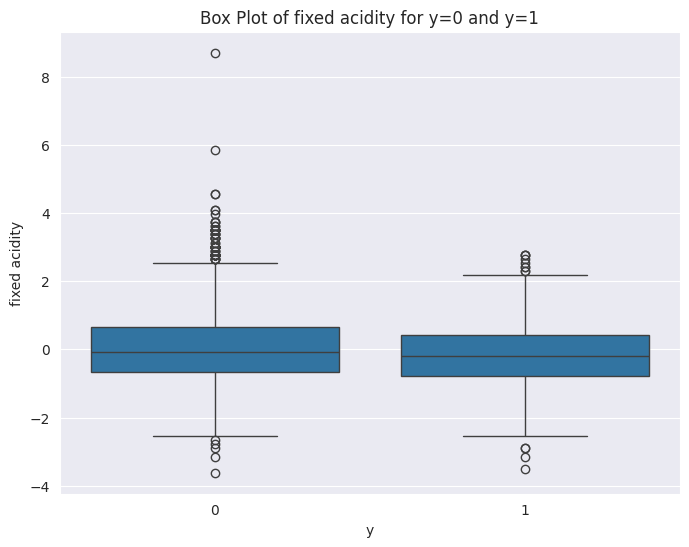

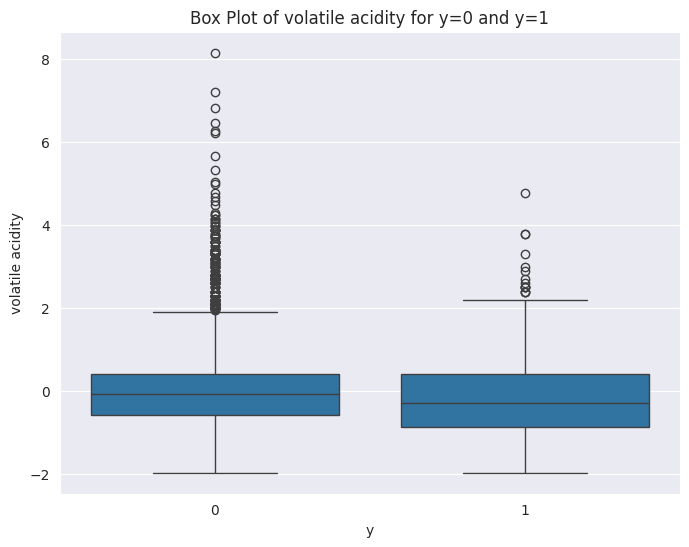

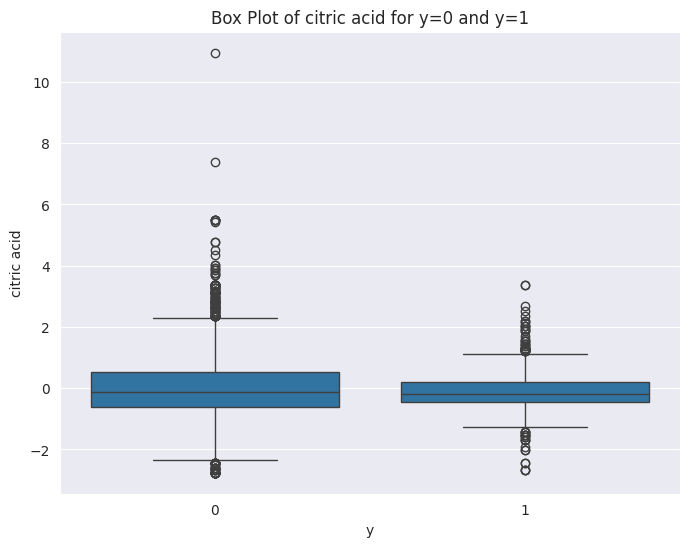

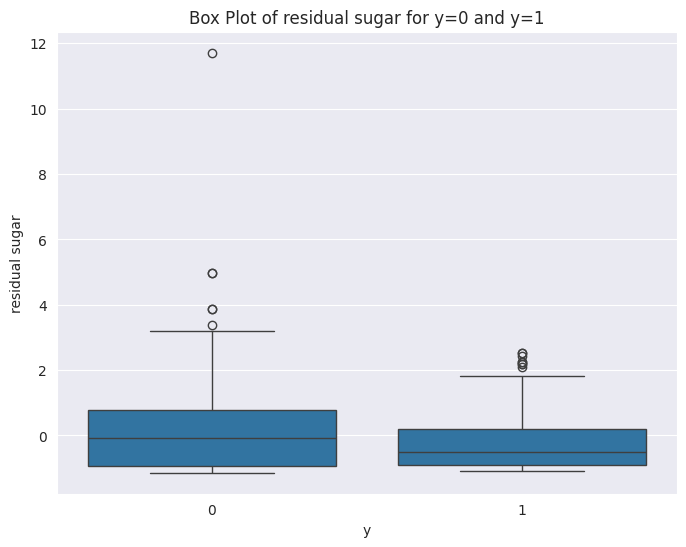

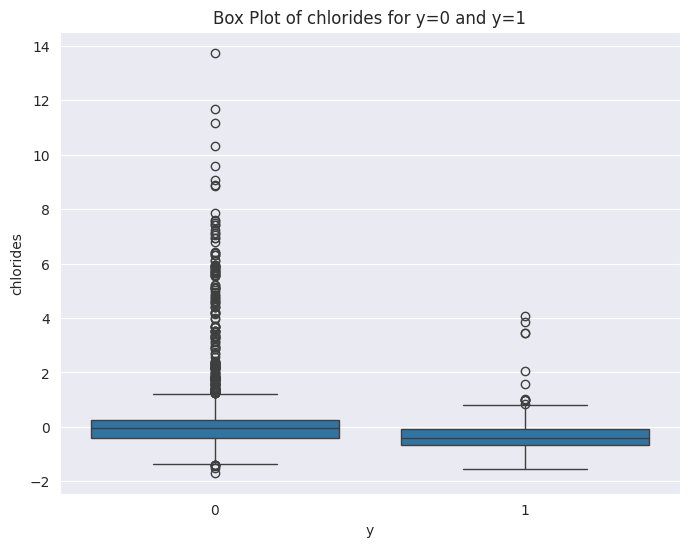

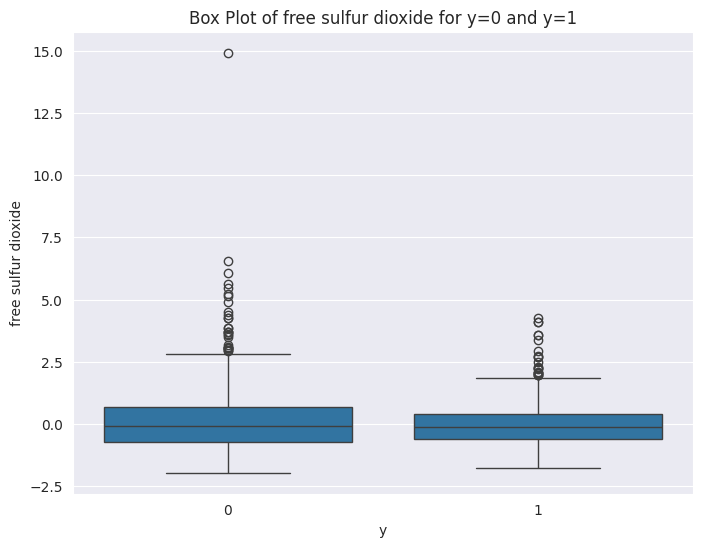

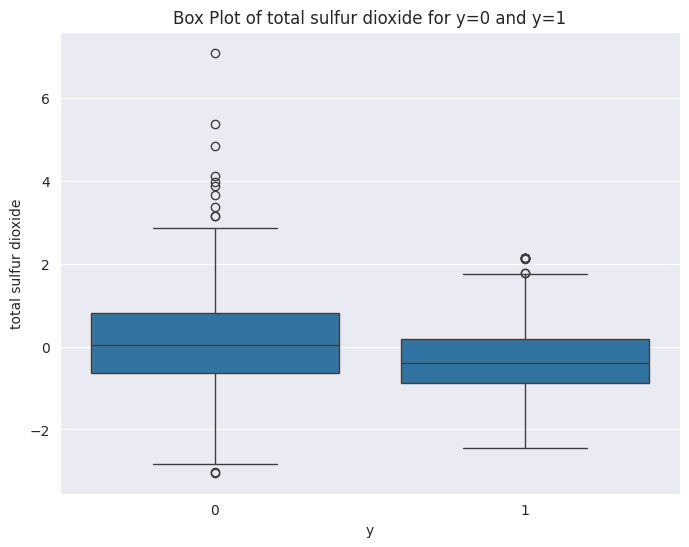

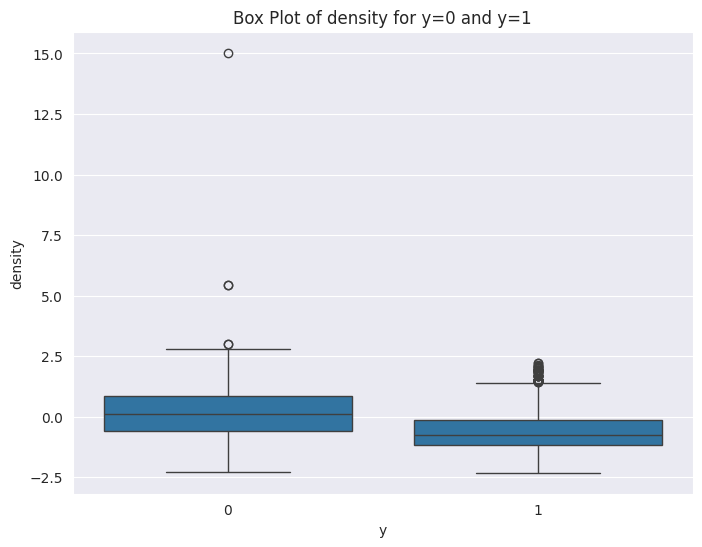

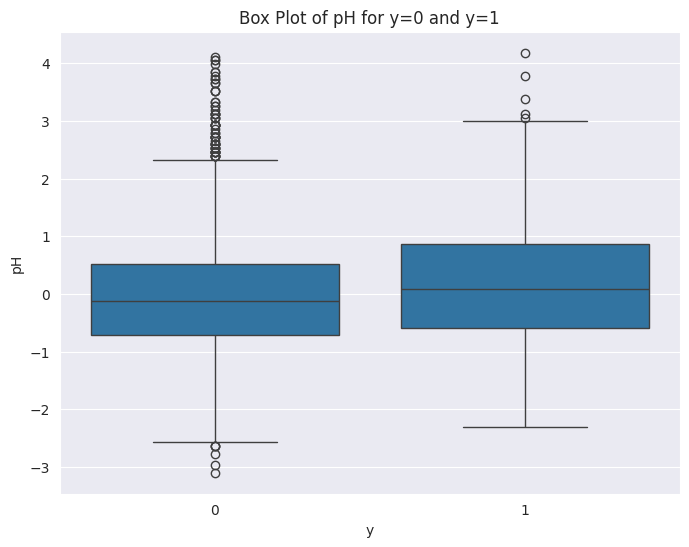

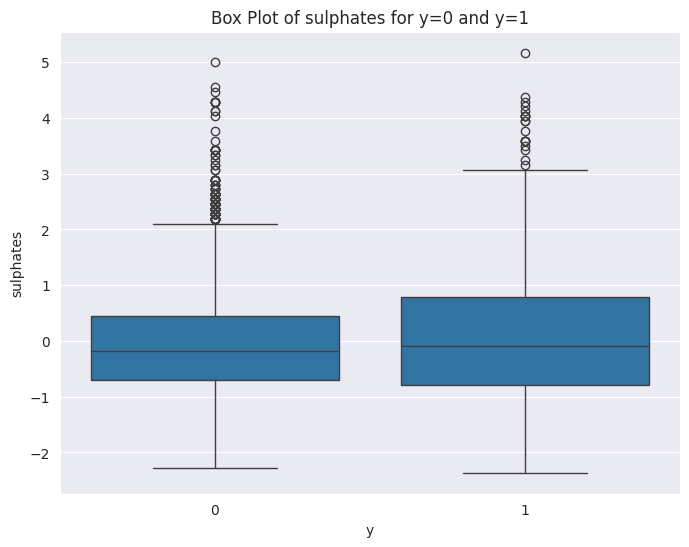

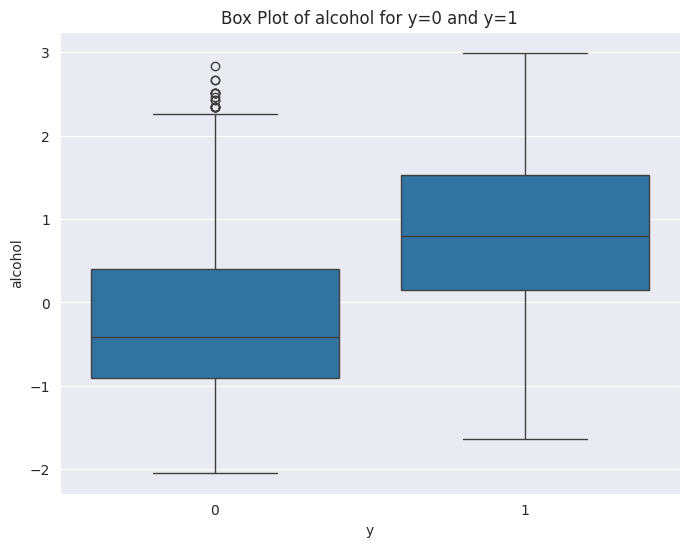

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df_depurada' is your DataFrame and 'y' is the target variable column

# Get the list of original variables (excluding 'y')
original_vars = df_depurada.columns.drop('y')

# Create box plots for each original variable
for var in original_vars:
    plt.figure(figsize=(8, 6))  # Adjust figure size if needed
    sns.boxplot(x='y', y=var, data=df_depurada)
    plt.title(f'Box Plot of {var} for y=0 and y=1')
    plt.xlabel('y')
    plt.ylabel(var)
    plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
from scipy.stats import chi2_contingency

def transform_and_chi2(df, target_variable='y', num_bins=4):
    """Transforms continuous variables to categorical using deciles and calculates chi-squared.

    Args:
        df (pd.DataFrame): Input DataFrame.
        target_variable (str): Name of the target variable column.
        num_bins (int): Number of bins (deciles by default).

    Returns:
        pd.DataFrame: DataFrame with chi-squared results for each variable.
    """

    chi2_results = []

    # Select continuous variables (exclude the target variable)
    continuous_vars = df.select_dtypes(include=['number']).columns
    continuous_vars = continuous_vars.drop(target_variable, errors='ignore')

    for var in continuous_vars:
        # Discretize the continuous variable using deciles
        discretizer = KBinsDiscretizer(n_bins=num_bins, encode='ordinal', strategy='quantile')
        df[var + '_cat'] = discretizer.fit_transform(df[[var]])

        # Create contingency table
        contingency_table = pd.crosstab(df[var + '_cat'], df[target_variable])

        # Calculate chi-squared
        chi2, p, dof, expected = chi2_contingency(contingency_table)

        chi2_results.append({'Variable': var, 'Chi-squared': chi2, 'p-value': p})

    return pd.DataFrame(chi2_results)


results_df = transform_and_chi2(df_depurada)
print(results_df)

                Variable  Chi-squared        p-value
0          fixed acidity    15.466715   1.458281e-03
1       volatile acidity    44.284583   1.313064e-09
2            citric acid   167.134983   5.286265e-36
3         residual sugar   146.729360   1.337374e-31
4              chlorides   365.873425   5.449830e-79
5    free sulfur dioxide    82.081577   1.097672e-17
6   total sulfur dioxide   155.761357   1.505854e-33
7                density   518.158114  5.538628e-112
8                     pH    64.542064   6.285059e-14
9              sulphates    38.441176   2.279447e-08
10               alcohol   681.931645  1.737284e-147


In [ ]:
### emepzamos con el SVM
from sklearn.model_selection import GridSearchCV

X = df_depurada.drop('y', axis=1)  # Features: all columns except 'y'
y = df_depurada['y']             # Target variable: 'y' column

[X_train, X_test, y_train, y_test] = train_test_split(X, y, test_size = 0.30, random_state = 101)

tabla_target=pd.DataFrame(y_test.value_counts())

# train the model on train set
model = SVC(kernel='linear')
model.fit(X_train, y_train)


# print prediction results
predictions = model.predict(X_train)
cm = confusion_matrix(y_train, predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy en train' , accuracy)
print(classification_report(y_train, predictions))


# print prediction results
predictions = model.predict(X_test)

cm = confusion_matrix(y_test, predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy en test' , accuracy)
print(classification_report(y_test, predictions))

[[2605   69]
 [ 595  159]]
accuracy en train 0.8063010501750292
              precision    recall  f1-score   support

           0       0.81      0.97      0.89      2674
           1       0.70      0.21      0.32       754

    accuracy                           0.81      3428
   macro avg       0.76      0.59      0.61      3428
weighted avg       0.79      0.81      0.76      3428

[[1123   41]
 [ 251   55]]
accuracy en test 0.8013605442176871
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      1164
           1       0.57      0.18      0.27       306

    accuracy                           0.80      1470
   macro avg       0.70      0.57      0.58      1470
weighted avg       0.77      0.80      0.76      1470



In [ ]:
coeficientes = model.coef_
print("Coeficientes del modelo lineal:")
print(coeficientes)

import pandas as pd
import matplotlib.pyplot as plt

# Asegúrate de que X_train tenga los nombres de las columnas correctos
# Si usaste df_depurada directamente como X antes del split:
nombres_variables = X_train.columns

# Crea un DataFrame para visualizar los coeficientes y sus variables
importancia_variables = pd.DataFrame({'Variable': nombres_variables, 'Importancia': coeficientes[0]})

# Ordena por importancia para facilitar la lectura
importancia_variables = importancia_variables.sort_values('Importancia', ascending=False)

print("\nImportancia de las variables (Coeficientes del modelo lineal):")
print(importancia_variables)

Coeficientes del modelo lineal:
[[ 0.    0.02 -0.09  0.54 -0.25 -0.    0.02 -0.8   0.23  0.2   0.68  0.16
  -0.08  0.05  0.14  0.04  0.07  0.02 -0.11  0.   -0.07 -0.56]]

Importancia de las variables (Coeficientes del modelo lineal):
                    Variable  Importancia
10                   alcohol     0.675154
3             residual sugar     0.544800
8                         pH     0.232628
9                  sulphates     0.198663
11         fixed acidity_cat     0.157850
14        residual sugar_cat     0.135777
16   free sulfur dioxide_cat     0.065993
13           citric acid_cat     0.053197
15             chlorides_cat     0.045000
17  total sulfur dioxide_cat     0.021099
6       total sulfur dioxide     0.020881
1           volatile acidity     0.016924
0              fixed acidity     0.004632
19                    pH_cat     0.002063
5        free sulfur dioxide    -0.002110
20             sulphates_cat    -0.068565
12      volatile acidity_cat    -0.076629
2         

In [ ]:
### validacion cruzada ###
from sklearn.model_selection import cross_val_score
results = cross_val_score(estimator=model, X=X, y=y, cv=5)
print(results)

[0.78 0.78 0.78 0.81 0.78]


In [ ]:
from imblearn.over_sampling import SMOTE

print("Balance de clases en y_train antes de SMOTE:")
print(y_train.value_counts())

print("Balance de clases en y_test:")
print(y_test.value_counts())

# Instancia SMOTE
# random_state para reproducibilidad
# sampling_strategy='auto' intentará balancear las clases automáticamente.
# Puedes especificar un diccionario si quieres proporciones específicas,
# por ejemplo, sampling_strategy={0: count_class_0, 1: count_class_0 * 0.5}
smote = SMOTE(random_state=42, sampling_strategy='auto') # Puedes ajustar sampling_strategy

# Aplica SMOTE solo al conjunto de entrenamiento
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Verifica el balance de clases después de aplicar SMOTE
print("\nBalance de clases en y_train después de SMOTE:")
print(y_train_smote.value_counts())

Balance de clases en y_train antes de SMOTE:
y
0    2674
1     754
Name: count, dtype: int64
Balance de clases en y_test:
y
0    1164
1     306
Name: count, dtype: int64

Balance de clases en y_train después de SMOTE:
y
1    2674
0    2674
Name: count, dtype: int64


In [ ]:

# train the model on train set
model = SVC(kernel='linear')
model.fit(X_train_smote, y_train_smote)


# print prediction results
predictions = model.predict(X_train_smote)
cm = confusion_matrix(y_train_smote, predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy en train' , accuracy)
print(classification_report(y_train_smote, predictions))


# print prediction results
predictions = model.predict(X_test)

cm = confusion_matrix(y_test, predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy en test' , accuracy)
print(classification_report(y_test, predictions))

[[1879  795]
 [ 558 2116]]
accuracy en train 0.7470082273747195
              precision    recall  f1-score   support

           0       0.77      0.70      0.74      2674
           1       0.73      0.79      0.76      2674

    accuracy                           0.75      5348
   macro avg       0.75      0.75      0.75      5348
weighted avg       0.75      0.75      0.75      5348

[[817 347]
 [ 77 229]]
accuracy en test 0.7115646258503401
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1164
           1       0.40      0.75      0.52       306

    accuracy                           0.71      1470
   macro avg       0.66      0.73      0.66      1470
weighted avg       0.81      0.71      0.74      1470



Fitting 10 folds for each of 6 candidates, totalling 60 fits


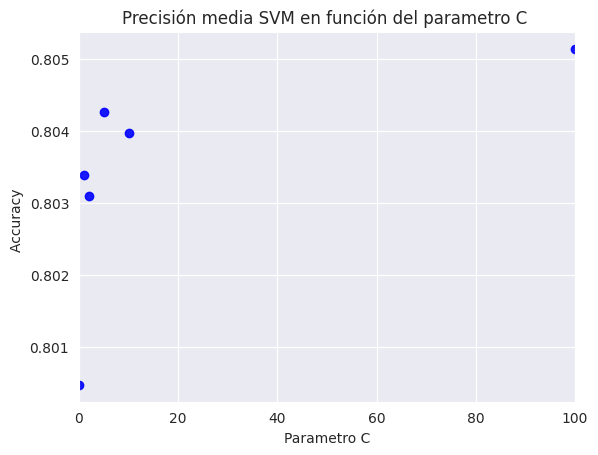

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.136703,0.028787,0.010239,0.002219,0.1,{'C': 0.1},0.781341,0.793003,0.795918,0.784257,0.816327,0.798834,0.825073,0.807580,0.807018,0.795322,0.800467,0.012979,6
1,0.292843,0.036047,0.011336,0.004001,1.0,{'C': 1},0.781341,0.793003,0.787172,0.793003,0.825073,0.810496,0.822157,0.813411,0.795322,0.812865,0.803384,0.014468,4
2,0.501112,0.165768,0.010117,0.002258,2.0,{'C': 2},0.781341,0.793003,0.784257,0.793003,0.825073,0.810496,0.819242,0.816327,0.795322,0.812865,0.803093,0.014701,5
3,0.798734,0.068457,0.011375,0.002973,5.0,{'C': 5},0.781341,0.795918,0.784257,0.795918,0.825073,0.810496,0.819242,0.816327,0.795322,0.818713,0.804261,0.014817,2
4,2.024665,1.824336,0.009477,0.000465,10.0,{'C': 10},0.781341,0.795918,0.781341,0.795918,0.825073,0.810496,0.819242,0.816327,0.795322,0.818713,0.803969,0.015231,3
5,15.595565,3.366196,0.012676,0.004104,100.0,{'C': 100},0.781341,0.798834,0.781341,0.795918,0.825073,0.810496,0.819242,0.816327,0.795322,0.827485,0.805138,0.016135,1


In [ ]:

####################### busqueda parametrica

########################################
## CASO 1. BUSQUEDA CON KERNEL LINEAL
########################################

## busqueda de parametros para el caso lineal ###
from sklearn.model_selection import GridSearchCV

# definimos los rangos de los parametros
param_grid_lineal = {'C': [0.1, 1, 2, 5, 10, 100] }

grid = GridSearchCV(SVC(kernel='linear'), param_grid_lineal, refit = True, cv=5, verbose = 1)

# ENTRENAMOS EN TRAIN Y BUSCAMOS EN TRAIN
resultados = grid.fit(X_train, y_train)

####### visualizar los resultados para decidir si debemos seguir buscando.
# Crear gráfico de dispersión
import matplotlib.pyplot as plt
import numpy as np

aux=pd.DataFrame(resultados.cv_results_)

plt.scatter(aux[['param_C']], aux[['mean_test_score']], color='b', alpha=0.9)

plt.xlabel('Parametro C')
plt.ylabel('Accuracy ')
plt.xlim(0, 100)
# Añadir título al gráfico
plt.title('Precisión media SVM en función del parametro C ')

# Mostrar el gráfico
plt.show()

display(aux)

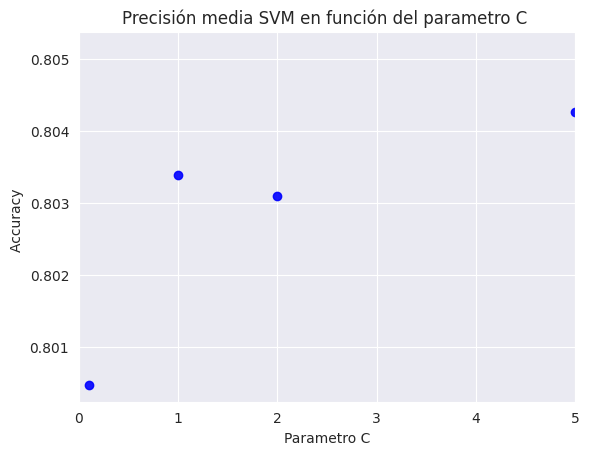

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.240329,0.024215,0.015326,0.000349,0.1,{'C': 0.1},0.781341,0.793003,0.795918,0.784257,0.816327,0.798834,0.825073,0.807580,0.807018,0.795322,0.800467,0.012979,6
1,0.637823,0.154913,0.017617,0.004237,1.0,{'C': 1},0.781341,0.793003,0.787172,0.793003,0.825073,0.810496,0.822157,0.813411,0.795322,0.812865,0.803384,0.014468,4
2,0.909583,0.130780,0.019144,0.007549,2.0,{'C': 2},0.781341,0.793003,0.784257,0.793003,0.825073,0.810496,0.819242,0.816327,0.795322,0.812865,0.803093,0.014701,5
3,1.787450,0.351524,0.017586,0.004593,5.0,{'C': 5},0.781341,0.795918,0.784257,0.795918,0.825073,0.810496,0.819242,0.816327,0.795322,0.818713,0.804261,0.014817,2
4,3.821734,3.045092,0.017479,0.004119,10.0,{'C': 10},0.781341,0.795918,0.781341,0.795918,0.825073,0.810496,0.819242,0.816327,0.795322,0.818713,0.803969,0.015231,3
5,26.000545,5.833266,0.020536,0.013256,100.0,{'C': 100},0.781341,0.798834,0.781341,0.795918,0.825073,0.810496,0.819242,0.816327,0.795322,0.827485,0.805138,0.016135,1


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

aux=pd.DataFrame(resultados.cv_results_)

plt.scatter(aux[['param_C']], aux[['mean_test_score']], color='b', alpha=0.9)

plt.xlabel('Parametro C')
plt.ylabel('Accuracy ')
plt.xlim(0, 5)
# Añadir título al gráfico
plt.title('Precisión media SVM en función del parametro C ')

# Mostrar el gráfico
plt.show()

display(aux)

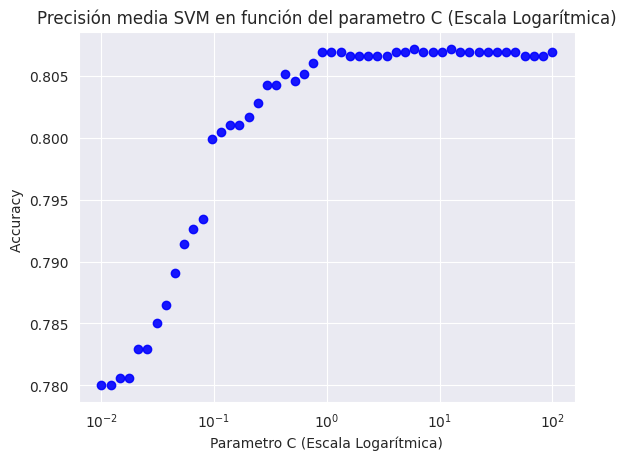

Mejores parámetros (GridSearchCV con escala logarítmica):
{'C': np.float64(5.963623316594643)}
Mejor estimador (GridSearchCV con escala logarítmica):
SVC(C=np.float64(5.963623316594643), kernel='linear')


In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid_lineal_log = {'C': np.logspace(-2, 2, 50) } # Genera 50 puntos entre 10^-2 (0.01) y 10^2 (100)

grid_log = GridSearchCV(SVC(kernel='linear'), param_grid_lineal_log, refit = True, cv=5, verbose = 0)

# ENTRENAMOS EN TRAIN Y BUSCAMOS EN TRAIN
resultados_log = grid_log.fit(X_train, y_train)

####### visualizar los resultados
import matplotlib.pyplot as plt
import pandas as pd

aux_log = pd.DataFrame(resultados_log.cv_results_)

plt.scatter(aux_log[['param_C']], aux_log[['mean_test_score']], color='b', alpha=0.9)

plt.xlabel('Parametro C (Escala Logarítmica)')
plt.ylabel('Accuracy ')
plt.xscale('log') # Establece la escala del eje x a logarítmica
# Añadir título al gráfico
plt.title('Precisión media SVM en función del parametro C (Escala Logarítmica)')

# Mostrar el gráfico
plt.show()

# print best parameter after tuning
print("Mejores parámetros (GridSearchCV con escala logarítmica):")
print(grid_log.best_params_)

# print how our model looks after hyper-parameter tuning
print("Mejor estimador (GridSearchCV con escala logarítmica):")
print(grid_log.best_estimator_)

BAYES SEARCH

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.6 MB/s eta 0:00:00


In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
# Define el espacio de búsqueda para el kernel lineal
param_space_linear = {'C': Real(0.01, 2.0)
 }

# Para el kernel lineal
bayes_search_linear = BayesSearchCV(
        estimator=SVC(kernel='linear'),
        search_spaces=param_space_linear,
        n_iter=50,      # Número de iteraciones de optimización
        cv=5,          # Validación cruzada
        random_state=42,
        n_jobs=-1,      # Usar todos los núcleos disponibles
        verbose=1       # Mostrar progreso
)

    # Entrenamos en train y buscamos en train
resultados_bayes_linear = bayes_search_linear.fit(X_train, y_train)

print(bayes_search_linear.best_params_)
print(bayes_search_linear.best_estimator_)
print("Mejor puntuación (Accuracy):", bayes_search_linear.best_score_)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [ ]:
best_model_bayes = resultados_bayes_linear.best_estimator_

predictions_test_bayes = best_model_bayes.predict(X_test)

cm = confusion_matrix(y_test, predictions_test_bayes)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy en test' , accuracy)
print(classification_report(y_test, predictions_test_bayes))



[[1123   41]
 [ 251   55]]
accuracy en test 0.8013605442176871
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      1164
           1       0.57      0.18      0.27       306

    accuracy                           0.80      1470
   macro avg       0.70      0.57      0.58      1470
weighted avg       0.77      0.80      0.76      1470



In [ ]:
model_b=SVC(C=1.2379879234196094, kernel='linear')

model_b.fit(X_train, y_train)

predictions_b = model_b.predict(X_test)

print("Informe de clasificación en el conjunto de prueba (Modelo entrenado con mejor C de BayesSearchCV):")
print(classification_report(y_test, predictions_b))

    # Imprimir la matriz de confusión
print("\nMatriz de confusión en el conjunto de prueba (Modelo entrenado con mejor C de BayesSearchCV):")
cm_test_best_bayes = confusion_matrix(y_test, predictions_b)
print(cm_test_best_bayes)

accuracy_test_best_bayes = accuracy_score(y_test, predictions_b)
print('\nAccuracy en el conjunto de prueba (Modelo entrenado con mejor C de BayesSearchCV):', accuracy_test_best_bayes)



Informe de clasificación en el conjunto de prueba (Modelo entrenado con mejor C de BayesSearchCV):
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      1164
           1       0.57      0.18      0.27       306

    accuracy                           0.80      1470
   macro avg       0.70      0.57      0.58      1470
weighted avg       0.77      0.80      0.76      1470


Matriz de confusión en el conjunto de prueba (Modelo entrenado con mejor C de BayesSearchCV):
[[1123   41]
 [ 251   55]]

Accuracy en el conjunto de prueba (Modelo entrenado con mejor C de BayesSearchCV): 0.8013605442176871


In [ ]:
aux.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_C', 'params', 'split0_test_score', 'split1_test_score',
       'split2_test_score', 'split3_test_score', 'split4_test_score',
       'split5_test_score', 'split6_test_score', 'split7_test_score',
       'split8_test_score', 'split9_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')

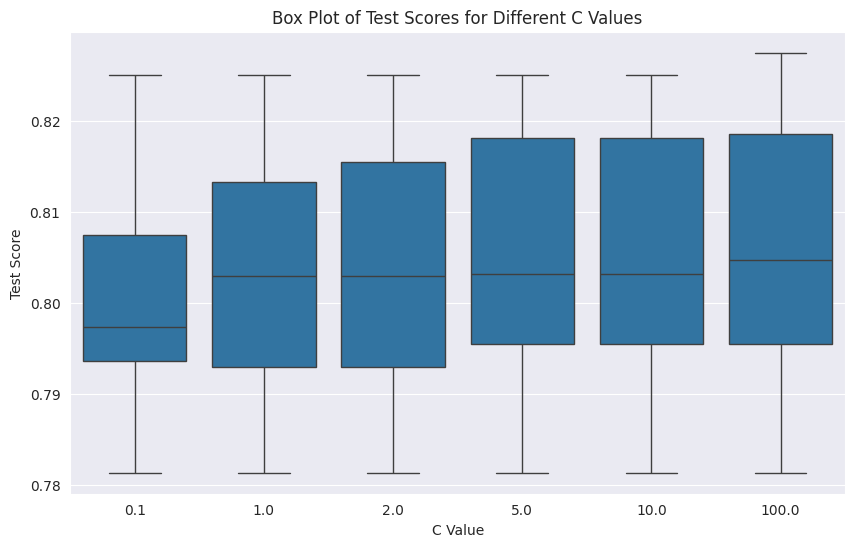

In [ ]:

# Melt the DataFrame to long format
scores_df = pd.melt(aux, id_vars=['param_C'], value_vars=[f'split{i}_test_score' for i in range(10)],
                    var_name='Split', value_name='Test Score')

# Create the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='param_C', y='Test Score', data=scores_df)
plt.title('Box Plot of Test Scores for Different C Values')
plt.xlabel('C Value')
plt.ylabel('Test Score')
plt.show()

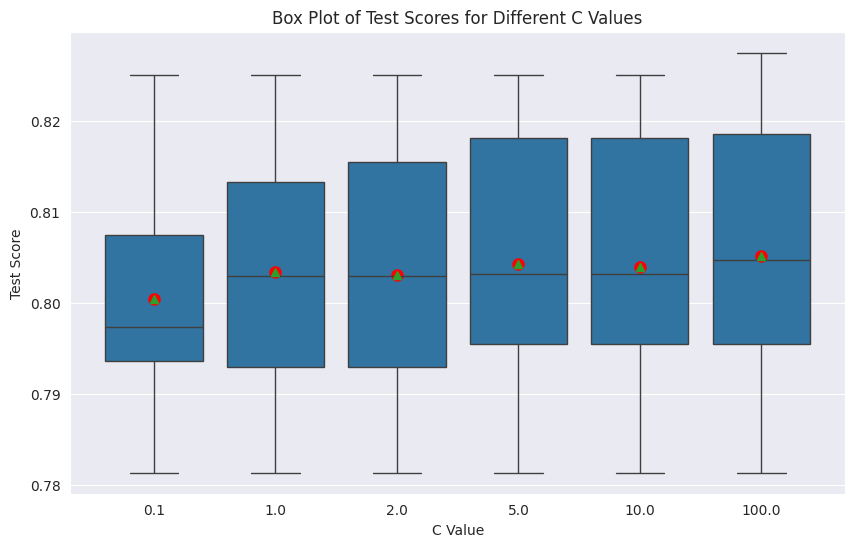

In [ ]:

# Create the box plot
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='param_C', y='Test Score', data=scores_df, showmeans=True)  # showmeans=True to display mean

# Add mean values as points
means = scores_df.groupby('param_C')['Test Score'].mean()  # Calculate mean for each C value
x_pos = np.arange(len(means))  # Get x-axis positions for the means
ax.plot(x_pos, means.values, 'o', color='red', markersize=8)  # Plot means as red circles

plt.title('Box Plot of Test Scores for Different C Values')
plt.xlabel('C Value')
plt.ylabel('Test Score')
plt.show()

Fitting 10 folds for each of 4 candidates, totalling 40 fits


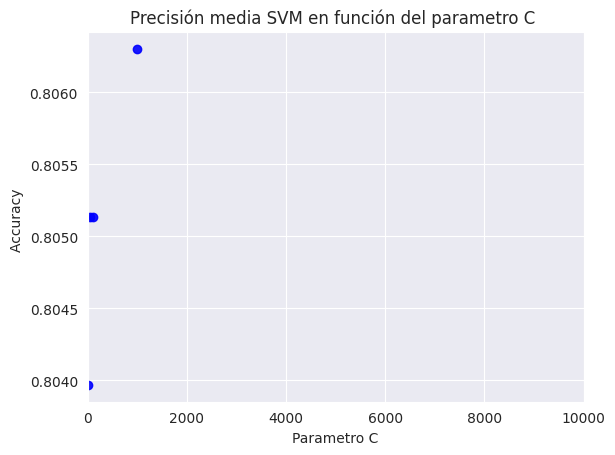

In [ ]:

## busqueda de parametros para el caso lineal ###
from sklearn.model_selection import GridSearchCV

# definimos los rangos de los parametros
param_grid_lineal = {'C': [10,50, 100,1000] }

grid = GridSearchCV(SVC(kernel='linear'), param_grid_lineal, refit = True, cv=10, verbose = 1)

# ENTRENAMOS EN TRAIN Y BUSCAMOS EN TRAIN
resultados = grid.fit(X_train, y_train)

####### visualizar los resultados para decidir si debemos seguir buscando.
# Crear gráfico de dispersión
import matplotlib.pyplot as plt
import numpy as np

aux=pd.DataFrame(resultados.cv_results_)

plt.scatter(aux[['param_C']], aux[['mean_test_score']], color='b', alpha=0.9)

plt.xlabel('Parametro C')
plt.ylabel('Accuracy ')
plt.xlim(0, 10000)
# Añadir título al gráfico
plt.title('Precisión media SVM en función del parametro C ')

# Mostrar el gráfico
plt.show()

Fitting 10 folds for each of 6 candidates, totalling 60 fits


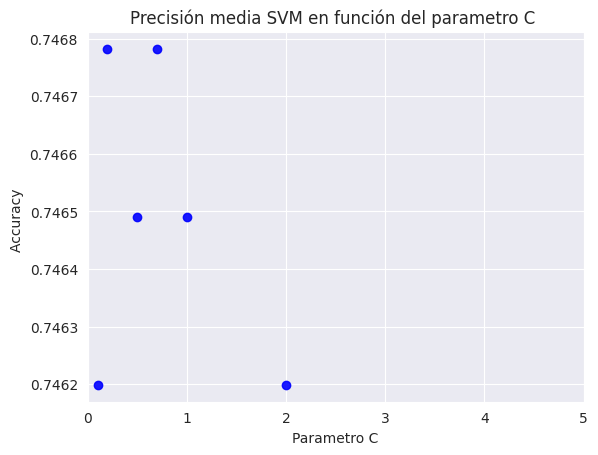

In [ ]:

## busqueda de parametros para el caso lineal ###
from sklearn.model_selection import GridSearchCV

# definimos los rangos de los parametros
param_grid_lineal = {'C': [0.1, 0.2, 0.5, 0.7, 1, 2] }

grid = GridSearchCV(SVC(kernel='linear'), param_grid_lineal, refit = True, cv=10, verbose = 1)

# ENTRENAMOS EN TRAIN Y BUSCAMOS EN TRAIN
resultados = grid.fit(X_train, y_train)

####### visualizar los resultados para decidir si debemos seguir buscando.
# Crear gráfico de dispersión
import matplotlib.pyplot as plt
import numpy as np

aux=pd.DataFrame(resultados.cv_results_)

plt.scatter(aux[['param_C']], aux[['mean_test_score']], color='b', alpha=0.9)

plt.xlabel('Parametro C')
plt.ylabel('Accuracy ')
plt.xlim(0, 5)
# Añadir título al gráfico
plt.title('Precisión media SVM en función del parametro C ')

# Mostrar el gráfico
plt.show()


Fitting 10 folds for each of 7 candidates, totalling 70 fits


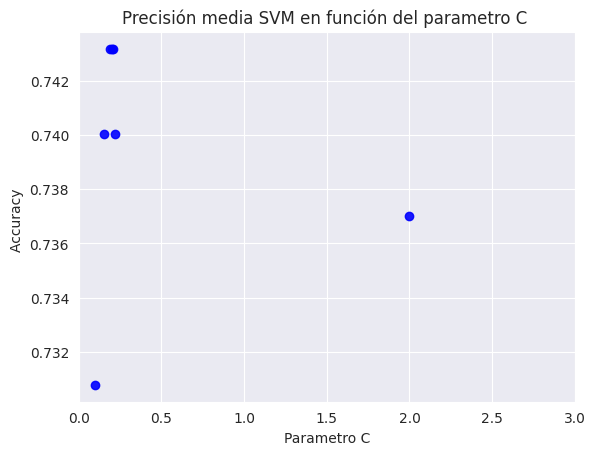

In [ ]:

## busqueda de parametros para el caso lineal ###
from sklearn.model_selection import GridSearchCV

# definimos los rangos de los parametros
param_grid_lineal = {'C': [0.1, 0.15, 0.19, 0.2, 0.21, 0.22, 2] }
grid = GridSearchCV(SVC(kernel='linear'), param_grid_lineal, refit = True, cv=10, verbose = 1 )

# ENTRENAMOS EN TRAIN Y BUSCAMOS EN TRAIN
resultados = grid.fit(X_train, y_train)

####### visualizar los resultados para decidir si debemos seguir buscando.
# Crear gráfico de dispersión
import matplotlib.pyplot as plt
import numpy as np

aux=pd.DataFrame(resultados.cv_results_)

plt.scatter(aux[['param_C']], aux[['mean_test_score']], color='b', alpha=0.9)

plt.xlabel('Parametro C')
plt.ylabel('Accuracy ')
plt.xlim(0, 3)
# Añadir título al gráfico
plt.title('Precisión media SVM en función del parametro C ')

# Mostrar el gráfico
plt.show()

In [ ]:


# print best parameter after tuning
print(grid.best_params_)

# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)


{'C': 0.19}
SVC(C=0.19, kernel='linear')


In [ ]:

##############################################
### PREDECIMOS CON EL  MEJOR MODELO LINEAL ###
##############################################
grid_predictions = grid.predict(X_test)

# print classification report
print(classification_report(y_test, grid_predictions))

#### DIFERENCIAS ??? ## SE MEJORA

cm = confusion_matrix(y_test, grid_predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy' , accuracy)


              precision    recall  f1-score   support

           0       0.70      0.90      0.79        86
           1       0.69      0.38      0.49        53

    accuracy                           0.70       139
   macro avg       0.69      0.64      0.64       139
weighted avg       0.70      0.70      0.67       139

[[77  9]
 [33 20]]
accuracy 0.697841726618705


In [ ]:
# train the model on train set
model = SVC(kernel='linear', C=0.19)
model.fit(X_train, y_train)

##############################################
### PREDECIMOS CON EL  MEJOR MODELO LINEAL ###
##############################################
predictions = model.predict(X_test)

# print classification report
print(classification_report(y_test, predictions))

#### DIFERENCIAS ??? ## SE MEJORA

cm = confusion_matrix(y_test, predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy' , accuracy)


              precision    recall  f1-score   support

           0       0.70      0.90      0.79        86
           1       0.69      0.38      0.49        53

    accuracy                           0.70       139
   macro avg       0.69      0.64      0.64       139
weighted avg       0.70      0.70      0.67       139

[[77  9]
 [33 20]]
accuracy 0.697841726618705


Index(['sbp', 'tobacco', 'ldl', 'adiposity', 'typea', 'obesity', 'alcohol',
       'age', 'famhist_Present'],
      dtype='object')


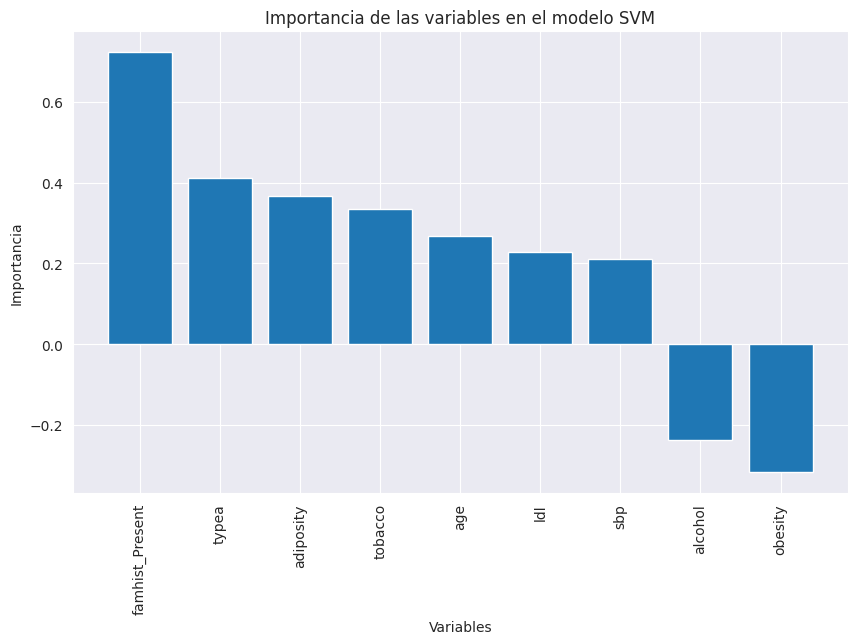

In [ ]:
coeficientes = model.coef_

import pandas as pd
import matplotlib.pyplot as plt

nombres_variables = X_train.columns
print(nombres_variables)
importancia_variables = pd.DataFrame({'Variable': nombres_variables, 'Importancia': coeficientes[0]})
importancia_variables = importancia_variables.sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(importancia_variables['Variable'], importancia_variables['Importancia'])
plt.xticks(rotation=90)
plt.xlabel('Variables')
plt.ylabel('Importancia')
plt.title('Importancia de las variables en el modelo SVM')
plt.show()

              precision    recall  f1-score   support

           0       0.72      0.93      0.81        86
           1       0.79      0.42      0.54        53

    accuracy                           0.73       139
   macro avg       0.75      0.67      0.68       139
weighted avg       0.75      0.73      0.71       139

[[80  6]
 [31 22]]
accuracy 0.7338129496402878
Index(['sbp', 'tobacco', 'ldl', 'adiposity', 'typea', 'age',
       'famhist_Present'],
      dtype='object')


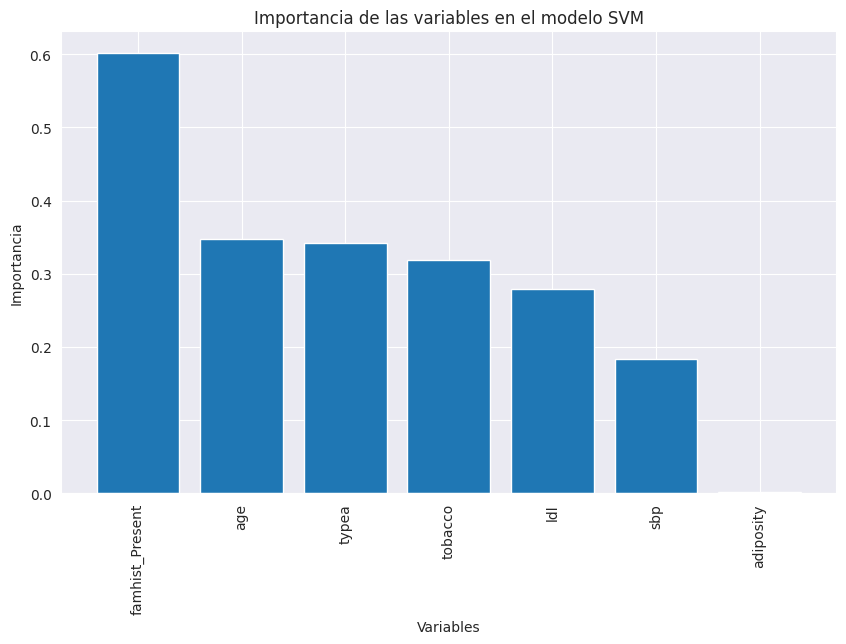

In [ ]:
## si entendemos lo que pasa vemos que algo raro pasa con alcohol y obesidad.....

X = df_depurada_dummies.drop(['chd', 'alcohol', 'obesity'], axis=1)
y = df_depurada_dummies["chd"]

[X_train, X_test, y_train, y_test] = train_test_split(X, y, test_size = 0.30, random_state = 101)


# train the model on train set
model = SVC(kernel='linear', C=0.19)
model.fit(X_train, y_train)

# print prediction results
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy' , accuracy)

coeficientes = model.coef_

nombres_variables = X_train.columns
print(nombres_variables)
importancia_variables = pd.DataFrame({'Variable': nombres_variables, 'Importancia': coeficientes[0]})
importancia_variables = importancia_variables.sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(importancia_variables['Variable'], importancia_variables['Importancia'])
plt.xticks(rotation=90)
plt.xlabel('Variables')
plt.ylabel('Importancia')
plt.title('Importancia de las variables en el modelo SVM')
plt.show()

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
SVC(C=10, gamma=0.01)
Media en el óptimo: 0.7434615384615384


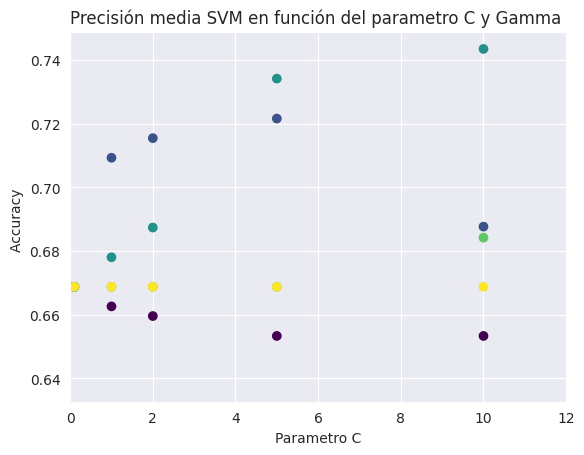

In [ ]:
### Cambiamos el kernel ###
########################################
## CASO 2. BUSQUEDA CON KERNEL GAUSIANO
########################################

param_grid_gausiano = {'C': [0.1, 1, 2, 5, 10, 100],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}

grid_gausiano = GridSearchCV(SVC(), param_grid_gausiano, refit = True, cv=5, verbose = 1)

# fitting the model for grid search
resultados = grid_gausiano.fit(X_train, y_train)

print(grid_gausiano.best_params_)

print(grid_gausiano.best_estimator_)

media_optimo = grid_gausiano.best_score_
print(f"Media en el óptimo: {media_optimo}")

############################################
#### visualizamos los resultados  GAUSIANO
##############################################
aux = pd.DataFrame(resultados.cv_results_)

# discretizar la variable sigma en 5 categorías

# factorizar la variable sigma
categorias, valores_enteros = pd.factorize(aux['param_gamma'])


# crear el gráfico de dispersión con colores basados en las categorías de sigma


plt.scatter(aux[['param_C']], aux[['mean_test_score']], c=categorias , cmap='viridis')
plt.xlabel('Parametro C')
plt.ylabel('Accuracy ')
plt.xlim(0, 12)
# Añadir título al gráfico
plt.title('Precisión media SVM en función del parametro C y Gamma ')
plt.show()

#display(aux)

Fitting 5 folds for each of 11 candidates, totalling 55 fits
{'C': 4.5, 'gamma': 0.1, 'kernel': 'rbf'}
SVC(C=4.5, gamma=0.1)
Media en el óptimo: 0.7246634615384615


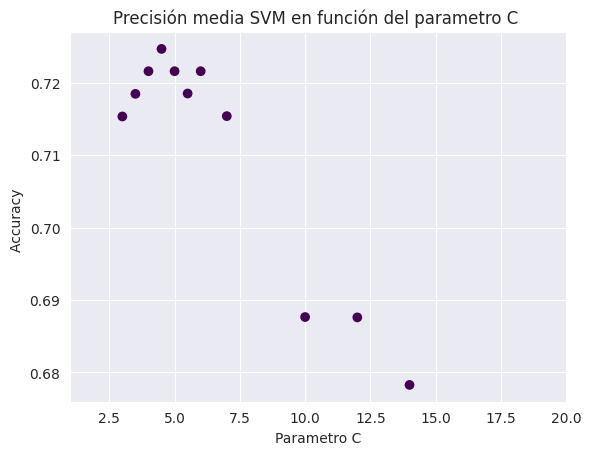

In [ ]:
########################################
## CASO 2. BUSQUEDA CON KERNEL GAUSIANO
########################################

param_grid_gausiano = {'C': [3,3.5, 4, 4.5, 5, 5.5, 6, 7, 10, 12, 14],
              'gamma': [0.1],
              'kernel': ['rbf']}

grid_gausiano = GridSearchCV(SVC(), param_grid_gausiano, refit = True, cv=5, verbose = 1)

#  # Para optimizar la puntuación F1:
#grid_gausiano = GridSearchCV(SVC(), param_grid_gausiano, scoring='f1', refit=True, cv=5, verbose=1)

# fitting the model for grid search
resultados = grid_gausiano.fit(X_train, y_train)

print(grid_gausiano.best_params_)

print(grid_gausiano.best_estimator_)

media_optimo = grid_gausiano.best_score_
print(f"Media en el óptimo: {media_optimo}")

############################################
#### visualizamos los resultados  GAUSIANO
##############################################
aux = pd.DataFrame(resultados.cv_results_)

# discretizar la variable sigma en 5 categorías

# factorizar la variable sigma
categorias, valores_enteros = pd.factorize(aux['param_gamma'])


# crear el gráfico de dispersión con colores basados en las categorías de sigma


plt.scatter(aux[['param_C']], aux[['mean_test_score']], c=categorias , cmap='viridis')
plt.xlabel('Parametro C')
plt.ylabel('Accuracy ')
plt.xlim(1,20 )
# Añadir título al gráfico
plt.title('Precisión media SVM en función del parametro C ')

plt.show()


              precision    recall  f1-score   support

           0       0.70      0.85      0.77        86
           1       0.63      0.42      0.50        53

    accuracy                           0.68       139
   macro avg       0.67      0.63      0.63       139
weighted avg       0.67      0.68      0.67       139

[[73 13]
 [31 22]]
accuracy 0.6834532374100719


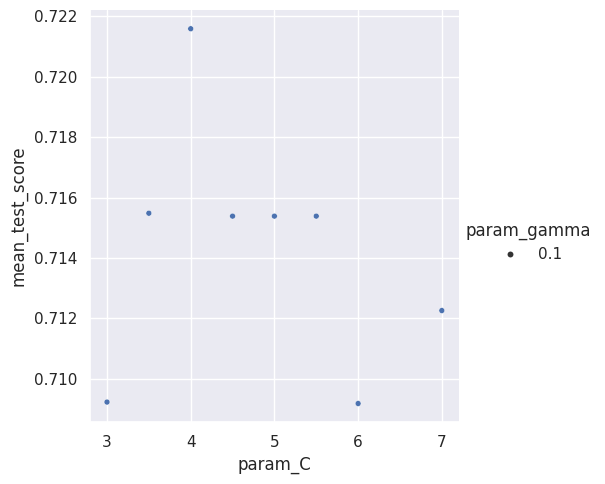

In [ ]:

#######################otra posibilidad para hacer el grafico mas sencillo ##

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")


sns.relplot(x="param_C", y="mean_test_score",  size='param_gamma' ,  data=aux);

##############################################
### PREDECIMOS CON EL  MEJOR MODELO GAUSIANO ENCONTRADO ###
##############################################
grid_predictions = grid_gausiano.predict(X_test)

# print classification report
print(classification_report(y_test, grid_predictions))

#### DIFERENCIAS ??? ## SE MEJORA

cm = confusion_matrix(y_test, grid_predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy' , accuracy)



In [ ]:
##############################################
### PREDECIMOS CON EL  MEJOR MODELO GAUSIANO ###
##############################################
grid_predictions = grid_gausiano.predict(X_test)

# print classification report
print(classification_report(y_test, grid_predictions))

#### DIFERENCIAS ??? ## SE MEJORA

cm = confusion_matrix(y_test, grid_predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy' , accuracy)


              precision    recall  f1-score   support

           0       0.70      0.85      0.77        86
           1       0.63      0.42      0.50        53

    accuracy                           0.68       139
   macro avg       0.67      0.63      0.63       139
weighted avg       0.67      0.68      0.67       139

[[73 13]
 [31 22]]
accuracy 0.6834532374100719


In [ ]:
# train the model on train set
model = SVC(kernel='rbf', C=4, gamma=0.1 )
model.fit(X_train, y_train)

##############################################
### PREDECIMOS CON EL  MEJOR MODELO LINEAL ###
##############################################
predictions = model.predict(X_train)

# print classification report
print(classification_report(y_train, predictions))

#### DIFERENCIAS ??? ## SE MEJORA

cm = confusion_matrix(y_train, predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy en train' , accuracy)



predictions = model.predict(X_test)

# print classification report
print(classification_report(y_test, predictions))

#### DIFERENCIAS ??? ## SE MEJORA

cm = confusion_matrix(y_test, predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy' , accuracy)


              precision    recall  f1-score   support

           0       0.82      0.92      0.87       216
           1       0.78      0.61      0.68       107

    accuracy                           0.81       323
   macro avg       0.80      0.76      0.78       323
weighted avg       0.81      0.81      0.81       323

[[198  18]
 [ 42  65]]
accuracy en train 0.8142414860681114
              precision    recall  f1-score   support

           0       0.70      0.85      0.77        86
           1       0.63      0.42      0.50        53

    accuracy                           0.68       139
   macro avg       0.67      0.63      0.63       139
weighted avg       0.67      0.68      0.67       139

[[73 13]
 [31 22]]
accuracy 0.6834532374100719


Fitting 5 folds for each of 32 candidates, totalling 160 fits
{'C': 7, 'gamma': 0.1, 'kernel': 'rbf'}
SVC(C=7, gamma=0.1)
Media en el óptimo: 0.5223363286264442


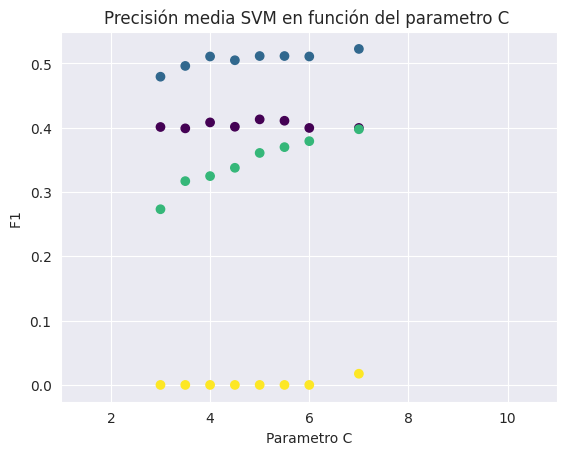

In [ ]:

param_grid_gausiano = {'C': [3,3.5, 4, 4.5, 5, 5.5, 6, 7],
              'gamma': [1, 0.1, 0.01, 0.001],
              'kernel': ['rbf']}

#grid_gausiano = GridSearchCV(SVC(), param_grid_gausiano, refit = True, cv=5, verbose = 1)

#  # Para optimizar la puntuación F1:
grid_gausiano = GridSearchCV(SVC(), param_grid_gausiano, scoring='f1', refit=True, cv=5, verbose=1)

# fitting the model for grid search
resultados = grid_gausiano.fit(X_train, y_train)

print(grid_gausiano.best_params_)

print(grid_gausiano.best_estimator_)

media_optimo = grid_gausiano.best_score_
print(f"Media en el óptimo: {media_optimo}")

############################################
#### visualizamos los resultados  GAUSIANO
##############################################
aux = pd.DataFrame(resultados.cv_results_)

# discretizar la variable sigma en 5 categorías

# factorizar la variable sigma
categorias, valores_enteros = pd.factorize(aux['param_gamma'])


# crear el gráfico de dispersión con colores basados en las categorías de sigma


plt.scatter(aux[['param_C']], aux[['mean_test_score']], c=categorias , cmap='viridis')
plt.xlabel('Parametro C')
plt.ylabel('F1 ')
plt.xlim(1,11 )
# Añadir título al gráfico
plt.title('Precisión media SVM en función del parametro C ')

plt.show()


Fitting 5 folds for each of 40 candidates, totalling 200 fits
{'C': 7, 'gamma': 0.1, 'kernel': 'rbf'}
SVC(C=7, gamma=0.1)
Media en el óptimo: 0.4774891774891774


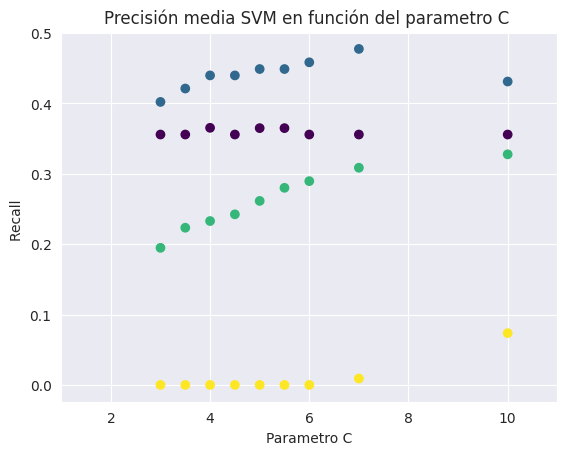

In [ ]:
param_grid_gausiano = {'C': [3,3.5, 4, 4.5, 5, 5.5, 6, 7,10,15],
              'gamma': [1, 0.1, 0.01, 0.001],
              'kernel': ['rbf']}

#grid_gausiano = GridSearchCV(SVC(), param_grid_gausiano, refit = True, cv=5, verbose = 1)

#  # Para optimizar la puntuación F1:
grid_gausiano = GridSearchCV(SVC(), param_grid_gausiano, scoring='recall', refit=True, cv=5, verbose=1)

# fitting the model for grid search
resultados = grid_gausiano.fit(X_train, y_train)

print(grid_gausiano.best_params_)

print(grid_gausiano.best_estimator_)

media_optimo = grid_gausiano.best_score_
print(f"Media en el óptimo: {media_optimo}")

############################################
#### visualizamos los resultados  GAUSIANO
##############################################
aux = pd.DataFrame(resultados.cv_results_)

# discretizar la variable sigma en 5 categorías

# factorizar la variable sigma
categorias, valores_enteros = pd.factorize(aux['param_gamma'])


# crear el gráfico de dispersión con colores basados en las categorías de sigma


plt.scatter(aux[['param_C']], aux[['mean_test_score']], c=categorias , cmap='viridis')
plt.xlabel('Parametro C')
plt.ylabel('Recall ')
plt.xlim(1,11 )
# Añadir título al gráfico
plt.title('Precisión media SVM en función del parametro C ')

plt.show()


In [ ]:
# train the model on train set
model = SVC(kernel='rbf', C=7, gamma=0.1 )
model.fit(X_train, y_train)

##############################################
### PREDECIMOS CON EL  MEJOR MODELO LINEAL ###
##############################################
predictions = model.predict(X_train)

# print classification report
print(classification_report(y_train, predictions))

#### DIFERENCIAS ??? ## SE MEJORA

cm = confusion_matrix(y_train, predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy en train' , accuracy)



predictions = model.predict(X_test)

# print classification report
print(classification_report(y_test, predictions))

#### DIFERENCIAS ??? ## SE MEJORA

cm = confusion_matrix(y_test, predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy' , accuracy)


              precision    recall  f1-score   support

           0       0.84      0.93      0.88       216
           1       0.81      0.64      0.71       107

    accuracy                           0.83       323
   macro avg       0.82      0.78      0.80       323
weighted avg       0.83      0.83      0.82       323

[[200  16]
 [ 39  68]]
accuracy en train 0.8297213622291022
              precision    recall  f1-score   support

           0       0.71      0.84      0.77        86
           1       0.62      0.43      0.51        53

    accuracy                           0.68       139
   macro avg       0.66      0.64      0.64       139
weighted avg       0.67      0.68      0.67       139

[[72 14]
 [30 23]]
accuracy 0.6834532374100719


Fitting 5 folds for each of 60 candidates, totalling 300 fits
{'C': 7, 'gamma': 0.1, 'kernel': 'rbf'}
SVC(C=7, gamma=0.1)
Media en el óptimo: 1.3014998726763434


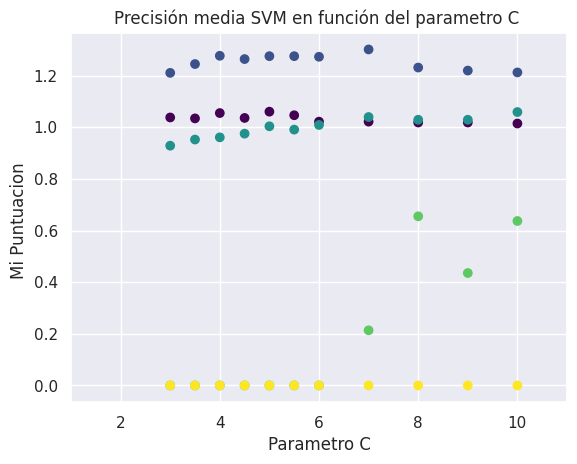

In [ ]:
from sklearn.metrics import precision_score, recall_score, make_scorer

def mi_funcion_de_puntuacion(y_true, y_pred):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    return 200 * recall + precision  # Recall con doble importancia

mi_scorer = make_scorer(mi_funcion_de_puntuacion, greater_is_better=True)

param_grid_gausiano = {'C': [3,3.5, 4, 4.5, 5, 5.5, 6, 7,8,9,10,15],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}

#grid_gausiano = GridSearchCV(SVC(), param_grid_gausiano, refit = True, cv=5, verbose = 1)

#  # Para optimizar la puntuación F1:
grid_gausiano = GridSearchCV(SVC(), param_grid_gausiano, scoring=mi_scorer, refit=True, cv=5, verbose=1)



# fitting the model for grid search
resultados = grid_gausiano.fit(X_train, y_train)

print(grid_gausiano.best_params_)

print(grid_gausiano.best_estimator_)

media_optimo = grid_gausiano.best_score_
print(f"Media en el óptimo: {media_optimo}")

############################################
#### visualizamos los resultados  GAUSIANO
##############################################
aux = pd.DataFrame(resultados.cv_results_)

# discretizar la variable sigma en 5 categorías

# factorizar la variable sigma
categorias, valores_enteros = pd.factorize(aux['param_gamma'])


# crear el gráfico de dispersión con colores basados en las categorías de sigma


plt.scatter(aux[['param_C']], aux[['mean_test_score']], c=categorias , cmap='viridis')
plt.xlabel('Parametro C')
plt.ylabel('Mi Puntuacion ')
plt.xlim(1,11 )
# Añadir título al gráfico
plt.title('Precisión media SVM en función del parametro C ')

plt.show()

Fitting 5 folds for each of 42 candidates, totalling 210 fits
{'C': 5, 'coef0': 0, 'degree': 3, 'kernel': 'poly'}
SVC(C=5, coef0=0, kernel='poly')
Media en el óptimo: 0.5231851631851632


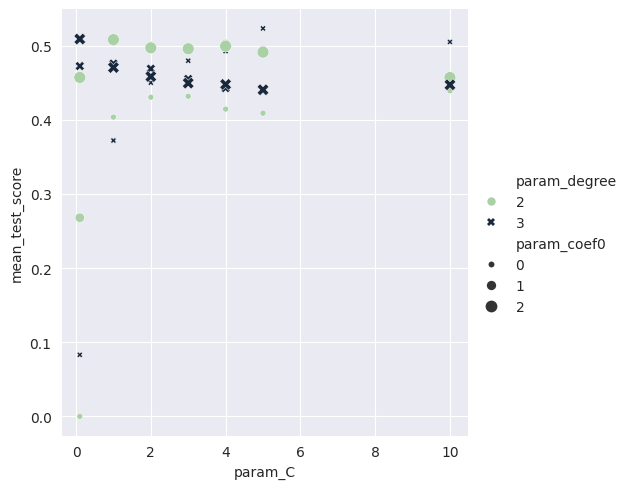

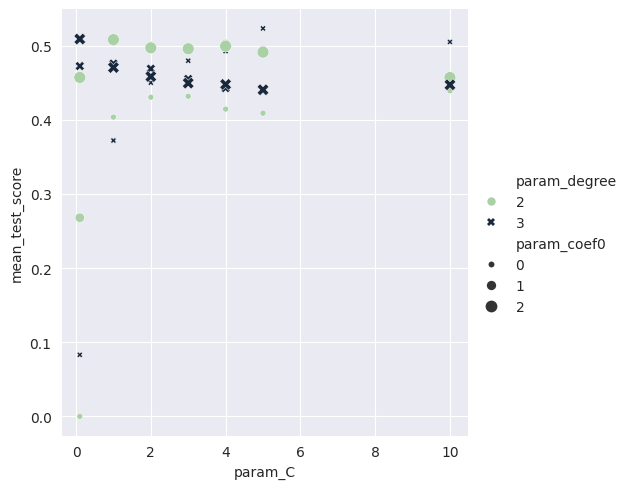

In [ ]:

###################################################
########################## MODELO POLINOMIAL SVM
##################################################


param_grid_poli = {'C': [0.1, 1, 2 ,3, 4,  5, 10], 'degree': [2, 3],
                   'coef0': [0, 1, 2], 'kernel': ['poly']}

grid_poli = GridSearchCV(SVC(), param_grid_poli, scoring='f1', refit = True, cv=5, verbose = 1)


resultados = grid_poli.fit(X_train, y_train)
aux= pd.DataFrame(resultados.cv_results_)

######### visualizamos los resultados ###

sns.relplot(x="param_C", y="mean_test_score", palette="ch:r=-.5,l=.75", hue="param_degree", size="param_coef0", style='param_degree',  data=aux);

## se puede probar tambien col (interesante)
print(grid_poli.best_params_)

print(grid_poli.best_estimator_)


media_optimo = grid_poli.best_score_
print(f"Media en el óptimo: {media_optimo}")


############################################
#### visualizamos los resultados  POlINOMIAL
##############################################
aux = pd.DataFrame(resultados.cv_results_)


######### visualizamos los resultados ###

sns.relplot(x="param_C", y="mean_test_score", palette="ch:r=-.5,l=.75", hue="param_degree", size="param_coef0", style='param_degree',  data=aux);




Fitting 5 folds for each of 27 candidates, totalling 135 fits
{'C': 1, 'coef0': 0, 'degree': 2, 'kernel': 'poly'}
SVC(C=1, coef0=0, degree=2, kernel='poly')
Media en el óptimo: 0.7338461538461538


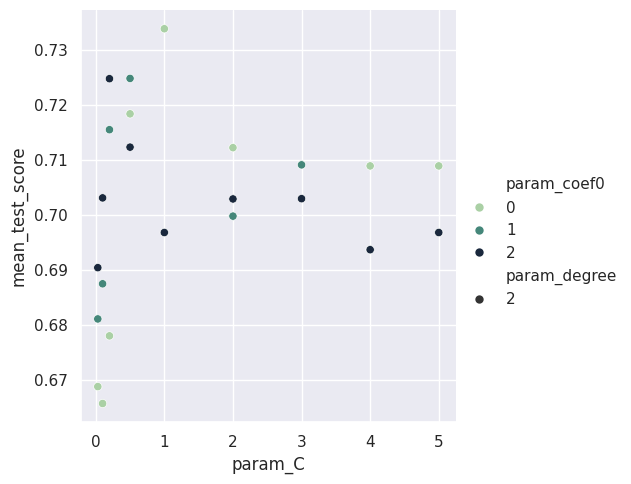

In [ ]:

###################################################
########################## MODELO POLINOMIAL SVM
##################################################


param_grid_poli = {'C': [0.1, 0.2,.03, 0.5, 1, 2 ,3, 4,  5], 'degree': [2],
                   'coef0': [0, 1, 2], 'kernel': ['poly']}

grid_poli = GridSearchCV(SVC(), param_grid_poli, refit = True, cv=5, verbose = 1)


resultados = grid_poli.fit(X_train, y_train)
aux= pd.DataFrame(resultados.cv_results_)

######### visualizamos los resultados ###

sns.relplot(x="param_C", y="mean_test_score", palette="ch:r=-.5,l=.75", hue="param_coef0", style='param_degree',  data=aux);

## se puede probar tambien col (interesante)
print(grid_poli.best_params_)

print(grid_poli.best_estimator_)

media_optimo = grid_poli.best_score_
print(f"Media en el óptimo: {media_optimo}")





Fitting 5 folds for each of 24 candidates, totalling 120 fits
{'C': 1, 'coef0': 0, 'degree': 2, 'kernel': 'poly'}
SVC(C=1, coef0=0, degree=2, kernel='poly')
Media en el óptimo: 0.7338461538461538


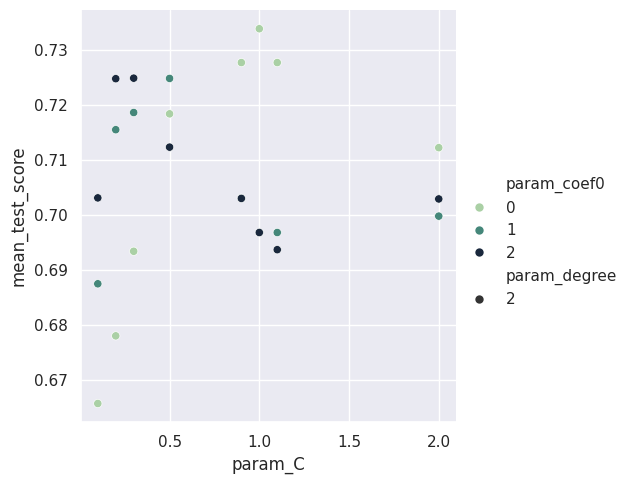

In [ ]:
###################################################
########################## MODELO POLINOMIAL SVM
##################################################


param_grid_poli = {'C': [0.1, 0.2, 0.3, 0.5, 0.9, 1, 1.1, 2 ], 'degree': [2],
                   'coef0': [0, 1, 2], 'kernel': ['poly']}

grid_poli = GridSearchCV(SVC(), param_grid_poli, refit = True, cv=5, verbose = 1)


resultados = grid_poli.fit(X_train, y_train)
aux= pd.DataFrame(resultados.cv_results_)

######### visualizamos los resultados ###

sns.relplot(x="param_C", y="mean_test_score", palette="ch:r=-.5,l=.75", hue="param_coef0", style='param_degree',  data=aux);

## se puede probar tambien col (interesante)
print(grid_poli.best_params_)

print(grid_poli.best_estimator_)

media_optimo = grid_poli.best_score_
print(f"Media en el óptimo: {media_optimo}")

In [ ]:
##############################################
### PREDECIMOS CON EL  MEJOR MODELO POLINOMIAL ###
##############################################
grid_predictions = grid_poli.predict(X_test)

# print classification report
print(classification_report(y_test, grid_predictions))

#### DIFERENCIAS ??? ## SE MEJORA

cm = confusion_matrix(y_test, grid_predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy' , accuracy)

              precision    recall  f1-score   support

           0       0.71      0.92      0.80        86
           1       0.74      0.38      0.50        53

    accuracy                           0.71       139
   macro avg       0.72      0.65      0.65       139
weighted avg       0.72      0.71      0.68       139

[[79  7]
 [33 20]]
accuracy 0.7122302158273381


In [ ]:
from sklearn.inspection import permutation_importance

# Ajustar el modelo con los mejores parámetros
best_model = grid_poli.best_estimator_
best_model.fit(X_train, y_train)

# Calcular la importancia de permutación
result = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Mostrar la importancia de cada variable
for i in result.importances_mean.argsort()[::-1]:
    print(
        f"{X_train.columns[i]:<8} "
        f"{result.importances_mean[i]:.3f}"
        f" +/- {result.importances_std[i]:.3f}"
    )

ldl      0.041 +/- 0.019
famhist_Present 0.034 +/- 0.010
tobacco  0.024 +/- 0.020
age      0.017 +/- 0.017
typea    0.006 +/- 0.006
adiposity 0.001 +/- 0.009
sbp      -0.003 +/- 0.011


In [ ]:
!pip install shap

  0%|          | 0/139 [00:00<?, ?it/s]

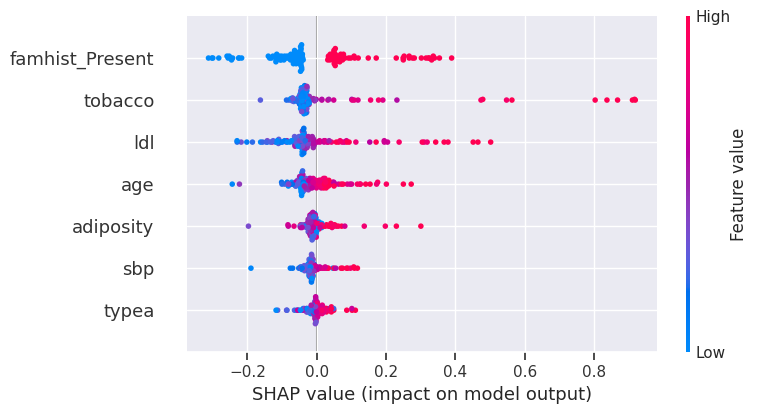

In [ ]:
import shap
explainer = shap.KernelExplainer(best_model.predict, X_train)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)



Fitting 5 folds for each of 5 candidates, totalling 25 fits
Mejores parámetros (LinearSVC con L1): {'C': 0.1}
Mejor estimador (LinearSVC con L1): LinearSVC(C=0.1, dual=False, max_iter=10000, penalty='l1', random_state=42)

Coeficientes del modelo LinearSVC con L1:
[[-0.    0.   -0.06  0.38 -0.04  0.01  0.   -0.42  0.16  0.11  0.27  0.11
  -0.1   0.04  0.07 -0.03  0.03  0.   -0.17 -0.03 -0.03 -0.2 ]]


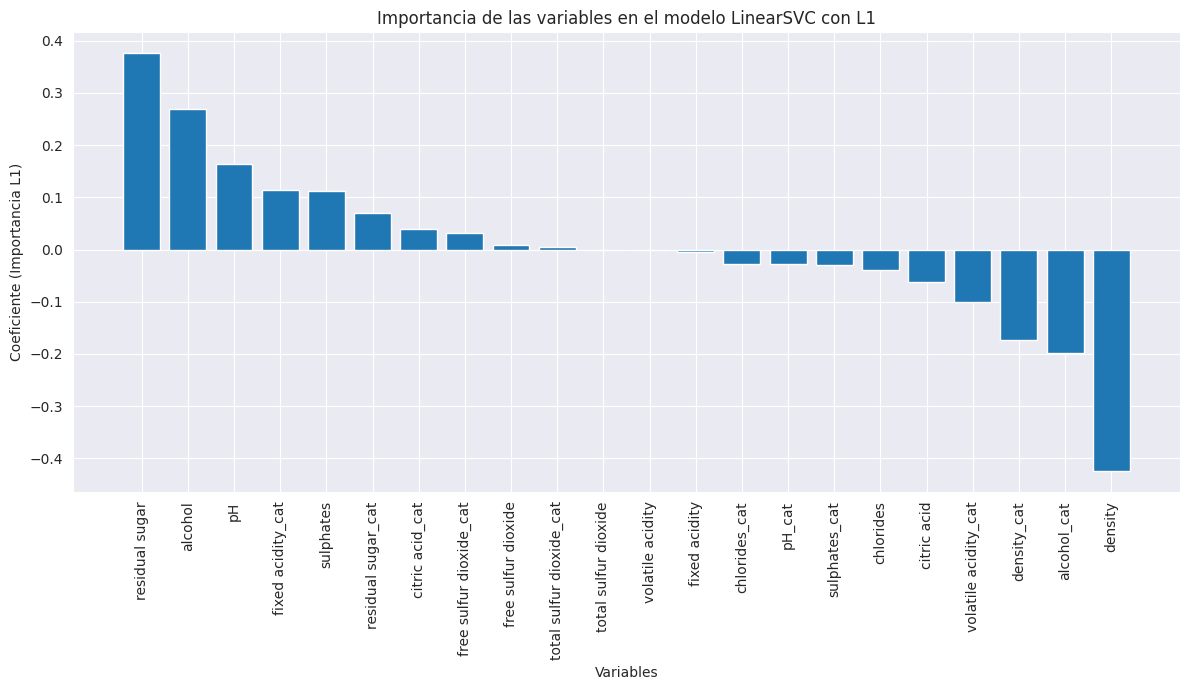


Informe de clasificación en el conjunto de prueba (LinearSVC con L1):
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1164
           1       0.53      0.25      0.34       306

    accuracy                           0.80      1470
   macro avg       0.68      0.60      0.61      1470
weighted avg       0.77      0.80      0.77      1470


Matriz de confusión en el conjunto de prueba (LinearSVC con L1):
[[1096   68]
 [ 229   77]]

Accuracy en el conjunto de prueba (LinearSVC con L1): 0.7979591836734694


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Definimos los rangos de los parámetros para LinearSVC con L1
# El parámetro alpha o C controla la regularización.
# En LinearSVC, el parámetro C es similar al C en SVC, donde valores más bajos
# corresponden a una regularización más fuerte (mayor penalización).
param_grid_linear_l1 = {'C': [0.01, 0.1, 1, 10, 100]}

# Instanciamos LinearSVC con penalización L1
# dual=False es necesario cuando penalty='l1' y n_samples > n_features
# max_iter puede ser necesario ajustarlo si no converge
lsvc = LinearSVC(penalty='l1', dual=False, max_iter=10000, random_state=42)

# Podemos usar GridSearchCV para encontrar el mejor C
grid_lsvc_l1 = GridSearchCV(lsvc, param_grid_linear_l1, refit=True, cv=5, verbose=1)

# Entrenamos en train
grid_lsvc_l1.fit(X_train, y_train)

print("Mejores parámetros (LinearSVC con L1):", grid_lsvc_l1.best_params_)
print("Mejor estimador (LinearSVC con L1):", grid_lsvc_l1.best_estimator_)

# Obtener los coeficientes del mejor modelo L1
best_lsvc_l1_model = grid_lsvc_l1.best_estimator_
coeficientes_l1 = best_lsvc_l1_model.coef_

print("\nCoeficientes del modelo LinearSVC con L1:")
print(coeficientes_l1)

# Visualizar los coeficientes (deberías ver algunos ceros)
import pandas as pd
import matplotlib.pyplot as plt

nombres_variables = X_train.columns
importancia_variables_l1 = pd.DataFrame({'Variable': nombres_variables, 'Importancia': coeficientes_l1[0]})
importancia_variables_l1 = importancia_variables_l1.sort_values('Importancia', ascending=False)

plt.figure(figsize=(12, 7))
plt.bar(importancia_variables_l1['Variable'], importancia_variables_l1['Importancia'])
plt.xticks(rotation=90)
plt.xlabel('Variables')
plt.ylabel('Coeficiente (Importancia L1)')
plt.title('Importancia de las variables en el modelo LinearSVC con L1')
plt.tight_layout()
plt.show()


# Evaluar en el conjunto de prueba
predictions_test_lsvc_l1 = best_lsvc_l1_model.predict(X_test)
print("\nInforme de clasificación en el conjunto de prueba (LinearSVC con L1):")
print(classification_report(y_test, predictions_test_lsvc_l1))
print("\nMatriz de confusión en el conjunto de prueba (LinearSVC con L1):")
print(confusion_matrix(y_test, predictions_test_lsvc_l1))
print('\nAccuracy en el conjunto de prueba (LinearSVC con L1):', accuracy_score(y_test, predictions_test_lsvc_l1))